# Exercise: Effect of rescaling on a k-neighbors models

In this exercise, we will use the **PRIMM** (Predict, Run, Investigate, Modify, Make) method to understand the importance of preprocessing numerical data—specifically, how feature scaling impacts distance-based algorithms like K-Nearest Neighbors (KNN).

### 1. Predict

Read the code in the "Run" section below, but **do not run it yet**.

We are using the `KNeighborsClassifier` on two features from the Breast Cancer dataset: `mean area` and `mean smoothness`.

- `mean area` has values that vary between approximately `143.5` and `2501.0`.
- `mean smoothness` has values that vary between approximately `0.05` and `0.16`.

We train a model on both the unscaled and scaled versions (using `StandardScaler`) of these two features.

**Predict:**

1. Will the decision boundaries for the model trained on unscaled data and scaled data be the same or different?
2. For the unscaled data, distances will be dominated by which feature? Why?

### **Answers:**
1. They will be different.

2. mean area because its values range from (143.5 to 2501.0) while mean smoothness ranges only from (0.05 to 0.16).

### 2. Run

Run the following code block to visualize the decision boundary of the KNN classifier on the two versions of the data.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Load the dataset
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target

In [3]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
# Select a subset of features with different orders of magnitude
features = ["mean texture", "mean smoothness"]
X_plot = X[features]

In [5]:
# Scale the data and keep it as a DataFrame
scaler = StandardScaler()
X_plot_scaled = pd.DataFrame(
    scaler.fit_transform(X_plot),
    columns=X_plot.columns
)

In [6]:
# Create a KNN classifier
clf = KNeighborsClassifier(n_neighbors=20)

In [7]:
def fit_and_plot_model(X_data, y_data, clf, ax):
    clf.fit(X_data, y_data)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_data,
        response_method="predict",
        alpha=0.5,
        ax=ax,
    )
    disp.ax_.scatter(X_data[features[0]], X_data[features[1]], c=y_data, s=20, edgecolor="k")
    disp.ax_.set_xlim((X_data[features[0]].min(), X_data[features[0]].max()))
    disp.ax_.set_ylim((X_data[features[1]].min(), X_data[features[1]].max()))
    return disp.ax_

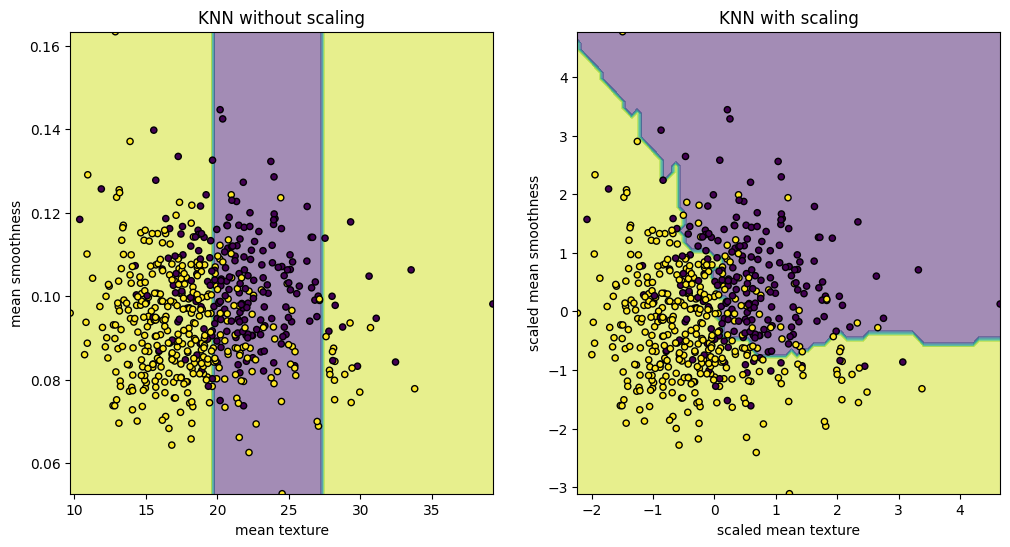

In [8]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

fit_and_plot_model(X_plot, y, clf, ax1)
ax1.set_title("KNN without scaling")

fit_and_plot_model(X_plot_scaled, y, clf, ax2)
ax2.set_xlabel(f"scaled {features[0]}")
ax2.set_ylabel(f"scaled {features[1]}")
_ = ax2.set_title("KNN with scaling")

plt.show()

### 3. Investigate

Review the output.

- Was your prediction correct?
- How did scaling affect the decision boundaries?
- Look at the scale of the x-axis and y-axis in both plots. Why does the plot on the left visually emphasize vertical decision boundaries (meaning decisions rely largely on the x-axis)?

### **Answers:**

1. Yes, the decision boundaries are different.

2. * With scaling the boundaries are more curved and the model is making decisions on both features equally.

   * Without scaling boundaries are vertical and the model is making decisions relying on only one feature (mean texture (mean area) because it has larger numeric range.).

3. Because the x‑axis feature (mean texture) has a much larger numeric range than mean smoothness.

### 4. Modify

Modify the code below to experiment with the algorithm:

1. Change the value of `n_neighbors` (e.g., to 1 or 50) and run the cell again. What changes do you observe in the boundary map?
2. Swap `StandardScaler` with `MinMaxScaler` (from `sklearn.preprocessing`). How does it change the scaled plot?

### **Answer:**

1. Change the value of n_neighbors (e.g., to 1 or 50) and run the cell again. What changes do you observe in the boundary map?


In [9]:
# Scale the data and keep it as a DataFrame
scaler = StandardScaler()
X_plot_scaled = pd.DataFrame(
    scaler.fit_transform(X_plot),
    columns=X_plot.columns
)

In [10]:
# Create a KNN classifier
clf = KNeighborsClassifier(n_neighbors = 1)

In [11]:
def fit_and_plot_model(X_data, y_data, clf, ax):
    clf.fit(X_data, y_data)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_data,
        response_method="predict",
        alpha=0.5,
        ax=ax,
    )
    disp.ax_.scatter(X_data[features[0]], X_data[features[1]], c=y_data, s=20, edgecolor="k")
    disp.ax_.set_xlim((X_data[features[0]].min(), X_data[features[0]].max()))
    disp.ax_.set_ylim((X_data[features[1]].min(), X_data[features[1]].max()))
    return disp.ax_

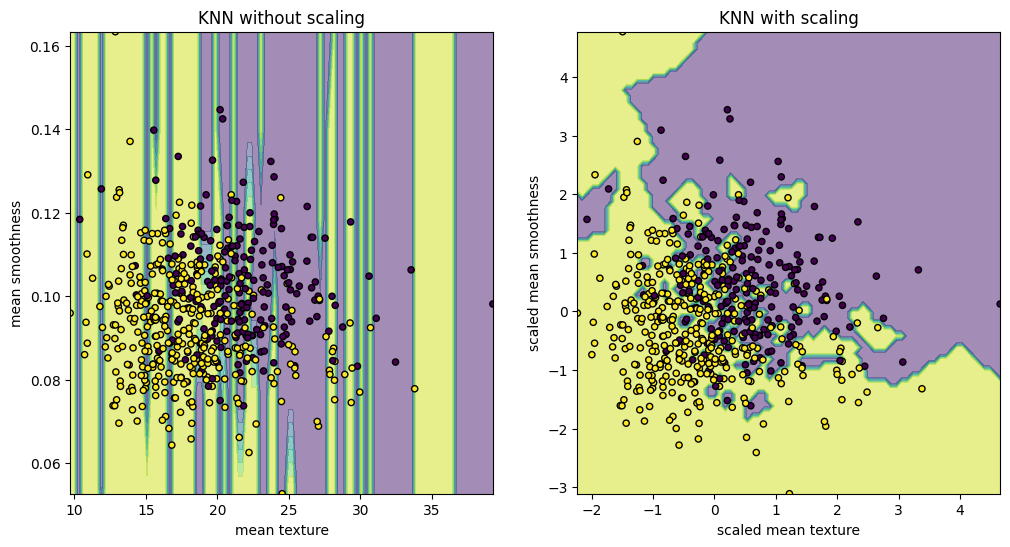

In [12]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

fit_and_plot_model(X_plot, y, clf, ax1)
ax1.set_title("KNN without scaling")

fit_and_plot_model(X_plot_scaled, y, clf, ax2)
ax2.set_xlabel(f"scaled {features[0]}")
ax2.set_ylabel(f"scaled {features[1]}")
_ = ax2.set_title("KNN with scaling")

plt.show()

* When i change the n_neighbors to 1 (n_neighbors = 1), the decision boundaries become very jagged and irregular. The model have high variance and it is overfitting.


### **Answer:**
2. Swap StandardScaler with MinMaxScaler (from sklearn.preprocessing). How does it change the scaled plot?

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [14]:
# Apply MinMaxScaler instead of StandardScaler
scaler = MinMaxScaler()
X_plot_scaled = pd.DataFrame(
    scaler.fit_transform(X_plot),
    columns=X_plot.columns
)

In [15]:
# Create a KNN classifier
clf = KNeighborsClassifier(n_neighbors=20)

In [16]:
def fit_and_plot_model(X_data, y_data, clf, ax):
    clf.fit(X_data, y_data)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_data,
        response_method="predict",
        alpha=0.5,
        ax=ax,
    )
    disp.ax_.scatter(X_data[features[0]], X_data[features[1]], c=y_data, s=20, edgecolor="k")
    disp.ax_.set_xlim((X_data[features[0]].min(), X_data[features[0]].max()))
    disp.ax_.set_ylim((X_data[features[1]].min(), X_data[features[1]].max()))
    return disp.ax_

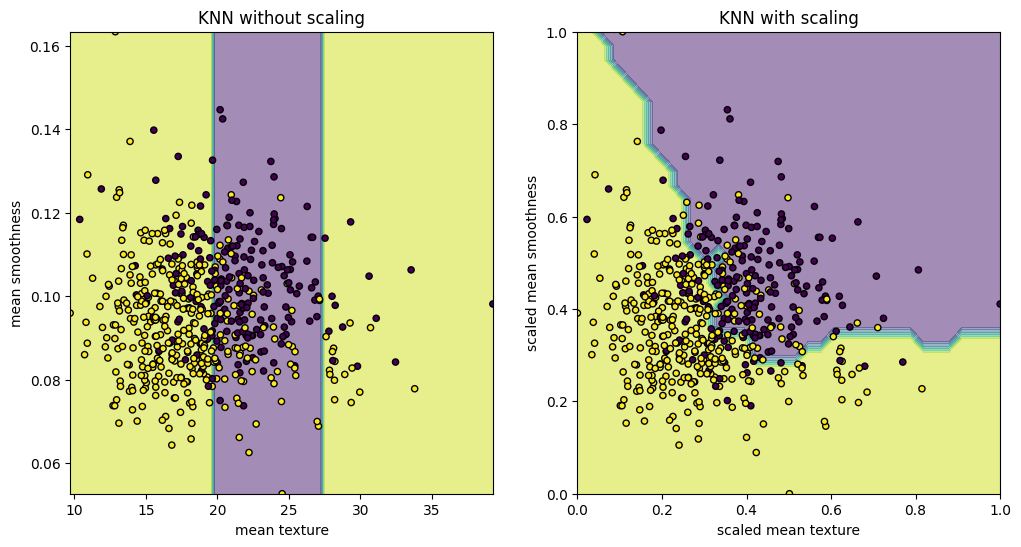

In [17]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

fit_and_plot_model(X_plot, y, clf, ax1)
ax1.set_title("KNN without scaling")

fit_and_plot_model(X_plot_scaled, y, clf, ax2)
ax2.set_xlabel(f"scaled {features[0]}")
ax2.set_ylabel(f"scaled {features[1]}")
_ = ax2.set_title("KNN with scaling")

plt.show()

* When switching from StandardScaler to MinMaxScaler, the decision boundary remains very similar.  But MinMaxScaler compresses all values into the range [0, 1].  so spacing between points may look slightly different.

### 5. Make

Now it's your turn. Use the same dataset but select two completely different features, like `mean radius` and `mean texture`.

- Print their minimum and maximum values to evaluate their magnitude differences.
- Apply `KNeighborsClassifier` WITHOUT scaling and plot the decision boundary.
- Apply `KNeighborsClassifier` WITH scaling and plot the decision boundary.
- Does scaling make as huge of an impact here? Why or why not?

### **Answer:**

In [18]:
features = ["mean radius" , "mean texture"]
X_new = X[features]

In [19]:
X_new.min()

,0
mean radius,6.981
mean texture,9.710


In [20]:
X_new.max()

,0
mean radius,28.11
mean texture,39.28


In [21]:
# Scale the data
scaler = StandardScaler()
X_new_scaled = pd.DataFrame(
    scaler.fit_transform(X_new),
    columns=X_new.columns
)

In [22]:
# KNN classifier
clf = KNeighborsClassifier(n_neighbors=20)

In [23]:
def fit_and_plot_model(X_data, y_data, clf, ax, title):
  clf.fit(X_data, y_data)
  disp = DecisionBoundaryDisplay.from_estimator(clf, X_data, response_method="predict", alpha=0.5, ax=ax )

  ax.scatter(X_data[features[0]], X_data[features[1]], c=y_data, s=20, edgecolor="k")
  ax.set_title(title)
  ax.set_xlabel(features[0])
  ax.set_ylabel(features[1])
  ax.set_xlim((X_data[features[0]].min(), X_data[features[0]].max()))
  ax.set_ylim((X_data[features[1]].min(), X_data[features[1]].max()))

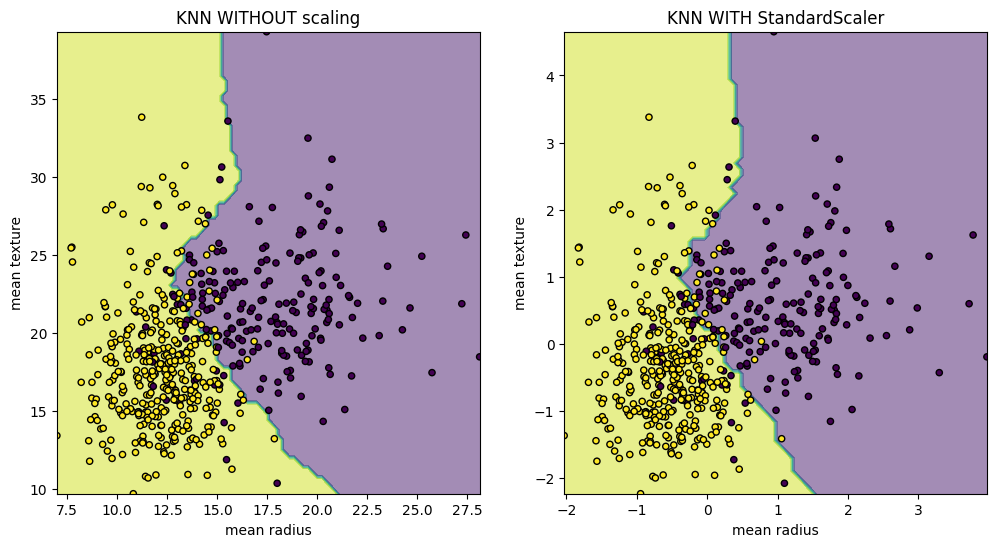

In [24]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

fit_and_plot_model(X_new, y, clf, ax1, "KNN WITHOUT scaling")
fit_and_plot_model(X_new_scaled, y, clf, ax2, "KNN WITH StandardScaler")

plt.show()

* No, the impact is smaller because mean radius (6 to 28) and mean texture (9 to 39) are much closer in scale, so neither feature dominates the distance calculation. This is very different from the earlier pair of features where mean area ( 143 to 2501) and mean smoothness( 0.05 to 0.16). Those two features have a large magnitude difference between them, so the feature with the larger numerical scale will dominate the distance calculation it was mean area.